## KNN

In [22]:
#importanos las variables
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Cargamos en dataset

In [24]:
iris = load_iris(as_frame=True)

In [25]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [26]:
dfIris = iris.frame
dfIris.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [27]:
dfIris.tail(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [28]:
#Cambiamos la columna de Target por Especie
dfIris.rename(columns={"target" : "species"}, inplace=True)

In [29]:
#Remplazamos los valores numericos por las especies
dfIris["species"] = dfIris["species"].map(
    {
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    }
)

In [30]:
dfIris.tail(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


## Variables predictoras y Variable objetivo

X (Variables predictoras) son aquellas que me permiten hacer la prediccion

y (objetivo) Lo que quiero predecir

In [31]:
#Variables predictoras
X = dfIris.drop(columns=["species"])

In [32]:
# Variable objetivo
y = dfIris["species"]

In [33]:
print("----Variables predictoras----")
print(X.columns)
print("----Variable Objetivo -----")
print(y.name)

----Variables predictoras----
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')
----Variable Objetivo -----
species


## División del conjunto de datos
Training Set: Datos para entrenamiento

Testing Set: Datos no vistos por el modelo, para prueba.

In [34]:
# Celda 23
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [35]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("------------------------")
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (120, 4)
X_test:  (30, 4)
------------------------
y_train:  (120,)
y_test:  (30,)


## Escalado de variables

In [36]:
scaler = StandardScaler()

In [37]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
print("-----------Datos sin escalar-----------")
print(X_train.head(5))
print("-----------Escalados-----------")
print(X_train_scaled[:5])

-----------Datos sin escalar-----------
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
22                4.6               3.6                1.0               0.2
15                5.7               4.4                1.5               0.4
65                6.7               3.1                4.4               1.4
11                4.8               3.4                1.6               0.2
42                4.4               3.2                1.3               0.2
-----------Escalados-----------
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]


## Entrenamiento del modelo

In [18]:
# Creamos una instancia del algoritmo
modelo = KNeighborsClassifier(
    n_neighbors = 3
)

In [19]:
# Entrenamos el modelo con los datos escalados
modelo.fit(
    X_train_scaled, 
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [20]:
prediccion = modelo.predict(X_test_scaled)

In [21]:
pd.DataFrame({
    "Especie real" : y_test.values,
    "Especie predicha" : prediccion
}).head(10)

,Especie real,Especie predicha
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


## Evaluacion del modelo
Las metricas a usar son: accuracy, precision, recall, f1-score

In [39]:
# Acurracy
accuracy = accuracy_score(y_test, prediccion)

In [40]:
print (f"Accuracy/Exactitud del modelo es: | { accuracy: .4f}")

Accuracy/Exactitud del modelo es: |  1.0000


In [43]:
# Matriz de confusion
matrizConfusion = confusion_matrix(y_test, prediccion)
matrizConfusion_df = pd.DataFrame (
    matrizConfusion,
    index = modelo.classes_,
    columns = modelo.classes_
)

In [44]:
matrizConfusion_df

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,0
virginica,0,0,11


In [45]:
# Matriz de metricas: Classification Report
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Variables de importancia

In [46]:
# importancia = modelo.feature_importances_
corr = dfIris.corr(numeric_only=True)

In [47]:
import seaborn as sns

<Axes: >

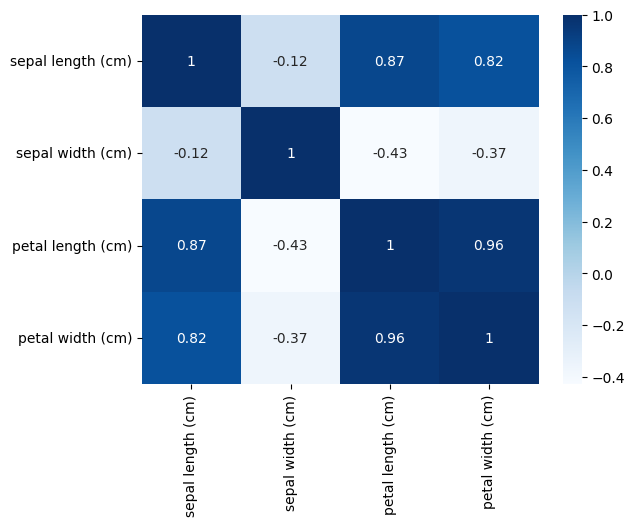

In [48]:
sns.heatmap(corr, annot=True, cmap="Blues")